In [12]:
###Base packages
import os
import re
import numpy as np
import pandas as pd
import scipy as sp
from scipy.stats import mode
from scipy import interpolate
from scipy import ndimage as ndi
from scipy.ndimage import label, find_objects, generate_binary_structure, binary_dilation
from scipy.ndimage import sobel, binary_fill_holes
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from glob import glob
from tqdm import tqdm
import hdbscan
from __future__ import annotations
from typing import Sequence, Optional, Union, Dict, Any
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Key import: this avoids a lot of common import pitfalls
import umap.umap_ as umap

UMAP PLOTTING

In [6]:
def fit_umap_on_dataframe(
    df: pd.DataFrame,
    feature_cols: Sequence[str],
    *,
    filename_col: str = "SourceCSV",
    n_components: int = 2,
    scale: bool = True,
    drop_nan_rows: bool = True,
    # Common UMAP knobs:
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    metric: str = "euclidean",
    random_state: Optional[int] = 0,
) -> Dict[str, Any]:
    """
    Fit UMAP on full dataset using selected columns.

    Returns a dict with:
      - 'umap_model': fitted UMAP object
      - 'scaler': fitted StandardScaler or None
      - 'feature_cols': columns used
      - 'fit_index': index of rows used (NaN rows dropped if enabled)
      - 'embedding': DataFrame with UMAP1..UMAPk for fit rows
    """
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"These feature_cols are not in df.columns: {missing}")

    X = df.loc[:, feature_cols].copy()
    for c in feature_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    if drop_nan_rows:
        valid_mask = ~X.isna().any(axis=1)
    else:
        valid_mask = np.ones(len(X), dtype=bool)

    fit_df = df.loc[valid_mask].copy()
    X_fit = X.loc[valid_mask].to_numpy(dtype=float)

    scaler = None
    if scale:
        scaler = StandardScaler()
        X_fit = scaler.fit_transform(X_fit)

    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    emb = umap_model.fit_transform(X_fit)

    emb_cols = [f"UMAP{i+1}" for i in range(emb.shape[1])]
    embedding = pd.DataFrame(emb, columns=emb_cols, index=fit_df.index)

    return {
        "umap_model": umap_model,
        "scaler": scaler,
        "feature_cols": feature_cols,
        "fit_index": fit_df.index,
        "embedding": embedding,
        "filename_col": filename_col,
        "scale": scale,
        "drop_nan_rows": drop_nan_rows,
        "umap_params": {
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "metric": metric,
            "n_components": n_components,
            "random_state": random_state,
        },
    }


def get_umap_embedding_for_plotting(
    df: pd.DataFrame,
    umap_bundle: Dict[str, Any],
    *,
    prefixes: Optional[Union[str, Sequence[str]]] = None,
    filename_col: Optional[str] = None,
) -> pd.DataFrame:
    """
    Join UMAP coordinates onto df (for rows used in fit), and optionally filter by
    filename prefix(es) for plotting.
    """

    base = df.loc[umap_bundle["fit_index"]].copy()
    out = base.join(umap_bundle["embedding"], how="inner")

    if prefixes is not None:
        if isinstance(prefixes, str):
            prefixes = [prefixes]
        prefixes = prefixes

        if filename_col is None:
            filename_col = umap_bundle.get("filename_col", "SourceCSV")
    
        if filename_col not in df.columns:
            raise ValueError(f"filename_col='{filename_col}' not found in df.columns")

        # If the filename column is a path, match on basename
        names = out[filename_col].astype(str).map(lambda s: s.split("\\")[-1].split("/")[-1])

        mask = np.zeros(len(out), dtype=bool)
        for pref in prefixes:
            mask |= names.str.startswith(pref)
        out = out.loc[mask].copy()

    return out

def plot_embedding_scatter(
    plot_df: pd.DataFrame,
    *,
    x: str = "UMAP1",
    y: str = "UMAP2",
    label_col: str | None = None,
    color_col: str | None = None,          # <-- NEW: heatmap coloring by a feature column
    cmap: str = "viridis",                 # <-- NEW: colormap for continuous coloring
    vmin: float | None = None,             # <-- NEW: clamp lower range
    vmax: float | None = None,             # <-- NEW: clamp upper range
    colorbar: bool = False,                 # <-- NEW: show colorbar for continuous coloring
    title: str | None = None,
    alpha_all: float = 0.25,
    alpha_label: float = 0.85,
    s_all: float = 10,
    s_label: float = 18,
    overlay_labeled_on_all: bool = False,
    show_legend: bool = True,
):
    """
    Scatter plot for embedding coordinates (UMAP/PCA/etc).

    Modes:
      1) color_col is provided (continuous "heatmap" coloring):
         - Points are colored by plot_df[color_col] (must be numeric).
         - If overlay_labeled_on_all is True and label_col is provided:
             background = all points faint gray
             foreground = labeled points colored by color_col
         - Otherwise:
             all points colored by color_col
         - Adds a colorbar (optional).

      2) color_col is None:
         Behaves like the original function: either single-color, or grouped colors by label_col.

    Notes:
      - Uses matplotlib defaults for categorical colors (labels).
      - Uses `cmap` for continuous coloring.
    """
    if x not in plot_df.columns or y not in plot_df.columns:
        raise ValueError(f"plot_df must contain columns '{x}' and '{y}'")

    if label_col is not None and label_col not in plot_df.columns:
        raise ValueError(f"label_col='{label_col}' not found in plot_df.columns")

    if color_col is not None and color_col not in plot_df.columns:
        raise ValueError(f"color_col='{color_col}' not found in plot_df.columns")

    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    if title:
        ax.set_title(title)

    # -----------------------------
    # Continuous "heatmap" coloring
    # -----------------------------
    if color_col is not None:
        vals = plot_df[color_col]

        # Require numeric (common gotcha: object dtype)
        if not pd.api.types.is_numeric_dtype(vals):
            raise ValueError(
                f"color_col='{color_col}' must be numeric (got dtype={vals.dtype}). "
                f"If it's a string column, use label_col instead."
            )

        # Matplotlib can't color NaNs well; we'll mask them out.
        valid_mask = vals.notna() & np.isfinite(vals.to_numpy(dtype=float, copy=False))

        # If overlaying labeled-on-all, make a faint gray background
        if overlay_labeled_on_all and (label_col is not None):
            ax.scatter(plot_df[x], plot_df[y], alpha=alpha_all, s=s_all, c="k")

            labeled_mask = (~plot_df[label_col].isna())
            fg_mask = labeled_mask & valid_mask

            sc = ax.scatter(
                plot_df.loc[fg_mask, x],
                plot_df.loc[fg_mask, y],
                c=plot_df.loc[fg_mask, color_col],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                alpha=alpha_label,
                s=s_label,
            )

            # optional legend for label groups (as outlines), without overriding heatmap colors
            if show_legend and labeled_mask.any():
                for lab, sub in plot_df.loc[labeled_mask].groupby(label_col, dropna=False):
                    ax.scatter(
                        sub[x], sub[y],
                        s=s_label,
                        facecolors="none",
                        edgecolors="k",
                        linewidths=0.6,
                        alpha=min(1.0, alpha_label + 0.1),
                        label=str(lab),
                    )
                ax.legend(title=label_col, loc="best", frameon=True)

        else:
            # Color all points by the feature (gray for NaNs)
            # Plot NaNs first so colored points sit on top
            nan_mask = ~valid_mask
            if nan_mask.any():
                ax.scatter(
                    plot_df.loc[nan_mask, x],
                    plot_df.loc[nan_mask, y],
                    alpha=alpha_all,
                    s=s_all,
                    c="lightgray",
                )

            sc = ax.scatter(
                plot_df.loc[valid_mask, x],
                plot_df.loc[valid_mask, y],
                c=plot_df.loc[valid_mask, color_col],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                alpha=alpha_label,
                s=s_label,
            )

            # If user also wants label legend (use outlines so we don't ruin the colormap)
            if label_col is not None and show_legend:
                for lab, sub in plot_df.loc[~plot_df[label_col].isna()].groupby(label_col, dropna=False):
                    ax.scatter(
                        sub[x], sub[y],
                        s=s_label,
                        facecolors="none",
                        edgecolors="k",
                        linewidths=0.6,
                        alpha=min(1.0, alpha_label + 0.1),
                        label=str(lab),
                    )
                ax.legend(title=label_col, loc="best", frameon=True)

        if colorbar:
            cb = fig.colorbar(sc, ax=ax)
            cb.set_label(color_col)

        plt.show()
        return fig, ax

    # -----------------------------
    # Original categorical behavior
    # -----------------------------

    # Case 1: no labels -> single-color plot, no legend
    if label_col is None:
        ax.scatter(plot_df[x], plot_df[y], alpha=alpha_label, s=s_label)
        plt.show()
        return fig, ax

    # Case 2: overlay labeled subset on all points
    if overlay_labeled_on_all:
        ax.scatter(plot_df[x], plot_df[y], alpha=alpha_all, s=s_all)

        labeled = plot_df.loc[~plot_df[label_col].isna()].copy()
        for label, sub in labeled.groupby(label_col, dropna=False):
            ax.scatter(sub[x], sub[y], alpha=alpha_label, s=s_label, label=str(label))

        if show_legend and len(labeled) > 0:
            ax.legend(title=label_col, loc="best", frameon=True)

        plt.show()
        return fig, ax

    # Case 3: label everything by group
    # for label, sub in plot_df.groupby(label_col, dropna=False):
    #     ax.scatter(sub[x], sub[y], alpha=alpha_label, s=s_label, label=str(label))
    colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
    "gold",
    "navy",
    "magenta",
    ]

    for i, (label, sub) in enumerate(plot_df.groupby(label_col, dropna=False)):
        ax.scatter(sub[x], sub[y], alpha=alpha_label, s=s_label, label=str(label), color=colors[i % len(colors)])
    
    if show_legend:
        ax.legend(title=label_col, loc="best", frameon=True)

    plt.show()
    return fig, ax

In [33]:
df = pd.read_csv('/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Figure3_4_Data.csv')

# df = df[df['Condition'] == 'Control']
conditions = ["Control","Baf 100 nM","Baf 10 uM","Chloroquine 100 nM","Chloroquine 10 uM","Apilimod 500 nM","Apilimod 50 uM"]
df = df[df['Condition'].isin(conditions)]

deepfeatures = [f"z{i:03d}" for i in range(0, 256)]
firstorderfeatures = ["Vol", "Dist_Nuc", "Dist_Mem", "Num_Connected_Objs", "Num_Branches"]
features=deepfeatures+firstorderfeatures

umap_bundle = fit_umap_on_dataframe(
    df,
    deepfeatures,
    n_components=2,
    scale=True,
    n_neighbors=20,
    min_dist=0.05,
    random_state=0,
)

/net/bmc-lab8/data/lab/boyer/users/jhday/conda/envs/inference_data/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


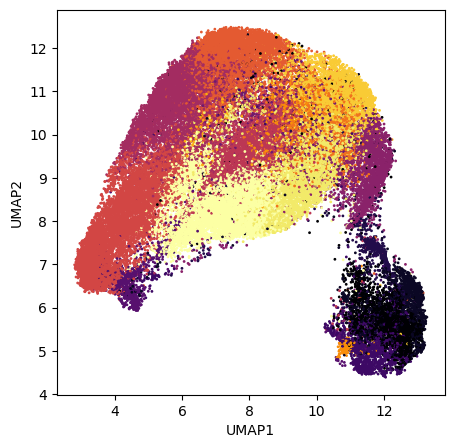

In [34]:
# for n in range(1,71,1):
plot_df = get_umap_embedding_for_plotting(
    df,
    umap_bundle,
    # prefixes=["r02c04_f06"],
    # filename_col="ParentImage",   # likely where your rxxcxx... token lives
)
clusterref = 'Learned Feature Cluster'
# clusterref = 'Measured Feature Cluster'
# clusterref = 'ch0_sum'
# counts = plot_df[clusterref].value_counts()
# keep_ids = counts[counts >= 300].index
# plot_df = plot_df[plot_df[clusterref].isin(keep_ids)]

# highlight = 'r02c04_f04'
# highlight = 'r02c04_f01'
# highlight = 'r02c05_f05'
# highlight = 'r05c04_f06'
# highlight = 'r06c04_f14-f15'
# highlight = 'r07c03_f25'

# highlight = 'r02c04'
# highlight = 'r03c09'
# highlight = 'r02c09'
# highlight = 'r05c04'
# highlight = 'r06c04'
# highlight = 'r07c03'

# highlight='Control'
# highlight='Serum Starvation'
# highlight='Baf 10 uM'

# highlight=n

# plot_df["Highlight"] = np.nan
# mask = plot_df["ParentImage"].astype(str).str.startswith(highlight)
# plot_df.loc[mask, "Highlight"] = highlight
# # plot_df.loc[plot_df["hdb_eps_0.2"] == highlight, "Highlight"] = True
# label_col='Highlight'

# Optional: create a label
# plot_df["Well"] = plot_df["ParentImage"].str.slice(0, 6)

# plot_df["Vol_nz"] = (plot_df["Vol"] - plot_df["Vol"].mean()) / plot_df["Vol"].std()

figure,axes=plot_embedding_scatter(plot_df, x="UMAP1", y="UMAP2", cmap='inferno', color_col=clusterref, s_all=.1, s_label=1, alpha_all=.1, alpha_label=1, overlay_labeled_on_all=True, show_legend=False)

In [8]:
def plot_umap_line_distributions_for_cluster(
    df: pd.DataFrame,
    cluster_value,
    xlim1,
    ylim1,
    xlim2,
    ylim2,
    *,
    cluster_col: str = "Measured Feature Cluster",
    umap1_col: str = "UMAP1",
    umap2_col: str = "UMAP2",
    bins=10,
    density: bool = True,
    linewidth: float = 2,
):
    """
    Plot line-based distributions of UMAP1 and UMAP2 for a single cluster/category.
    """
    sub = df[df[cluster_col] == cluster_value].copy()

    if sub.empty:
        raise ValueError(f"No rows found where {cluster_col} == {cluster_value}")

    def _plot_line_distribution(values, xlab, title, xlim, ylim):
        hist, edges = np.histogram(values.dropna(), bins=bins, density=density)
        centers = (edges[:-1] + edges[1:]) / 2

        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(centers, hist, linewidth=linewidth)
        ax.set_title(title)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xlabel(xlab)
        ax.set_ylabel("Density" if density else "Count")
        plt.tight_layout()
        return fig, ax

    fig1, ax1 = _plot_line_distribution(
        sub[umap1_col],
        umap1_col,
        f"{umap1_col} distribution for {cluster_col}={cluster_value}",
        xlim1,
        ylim1
    )

    fig2, ax2 = _plot_line_distribution(
        sub[umap2_col],
        umap2_col,
        f"{umap2_col} distribution for {cluster_col}={cluster_value}",
        xlim2,
        ylim2
    )

    return fig1, ax1, fig2, ax2

Cluster Combination Enrichment

In [21]:
def make_cluster_enrichment_table(
    df,
    *,
    clusterF_col: str,
    clusterD_col: str,
    condition: str | None = None,
    index_col: str | None = None,
    condition_col: str = "Condition",
    pseudocount: float = 0.0,
):
    """
    Build a cluster-overlap enrichment analysis between two dataframes that
    represent the same underlying objects but contain different clustering columns.

    Parameters
    ----------
    df_features : pd.DataFrame
        First dataframe, containing the feature-based cluster assignments.
    df_deep : pd.DataFrame
        Second dataframe, containing the deep/learned cluster assignments.
    clusterF_col : str
        Column in df_features containing the feature-based cluster IDs.
    clusterD_col : str
        Column in df_deep containing the deep/learned cluster IDs.
    condition : str or None, optional
        If provided, keep only rows whose Condition column contains this string.
    index_col : str or None, optional
        Column to use as the merge key. If None, merge on the dataframe index.
    condition_col : str, default "Condition"
        Name of the condition column.
    pseudocount : float, default 0.0
        Value added to observed and expected before computing enrichment.
        Useful for avoiding divide-by-zero / inf in sparse tables.

    Returns
    -------
    merged_df : pd.DataFrame
        Dataframe with columns: index, clusterF, clusterD, Condition
        (filtered if condition is provided).
    count_table : pd.DataFrame
        Raw contingency table of overlaps.
    expected_table : pd.DataFrame
        Expected counts under independence.
    enrichment_table : pd.DataFrame
        Observed / expected table.
    log2_enrichment_table : pd.DataFrame
        log2(observed / expected) table.
    """


    left = df[[clusterF_col, condition_col]].copy()
    left = left.rename(columns={clusterF_col: "clusterF", condition_col: "Condition"})
    left["index"] = df.index

    right = df[[clusterD_col]].copy()
    right = right.rename(columns={clusterD_col: "clusterD"})
    right["index"] = df.index

    merged_df = pd.merge(left, right, on="index", how="inner")

    # optional condition filter
    if condition is not None:
        merged_df = merged_df[
            merged_df["Condition"].astype(str).str.contains(condition, na=False, regex=False)
        ].copy()

    if merged_df.empty:
        raise ValueError("Merged dataframe is empty after merging/filtering.")

    # raw contingency table
    count_table = pd.crosstab(
        merged_df["clusterF"],
        merged_df["clusterD"]
    )

    # expected counts under independence
    row_totals = count_table.sum(axis=1).to_numpy()[:, None]
    col_totals = count_table.sum(axis=0).to_numpy()[None, :]
    total = count_table.values.sum()

    expected = (row_totals @ col_totals) / total
    expected_table = pd.DataFrame(
        expected,
        index=count_table.index,
        columns=count_table.columns
    )

    # enrichment
    observed_vals = count_table.astype(float).values
    expected_vals = expected_table.astype(float).values

    enrichment_vals = (observed_vals + pseudocount) / (expected_vals + pseudocount)
    enrichment_table = pd.DataFrame(
        enrichment_vals,
        index=count_table.index,
        columns=count_table.columns
    )

    # log2 enrichment
    with np.errstate(divide="ignore", invalid="ignore"):
        log2_enrichment_vals = np.log2(enrichment_vals)

    log2_enrichment_table = pd.DataFrame(
        log2_enrichment_vals,
        index=count_table.index,
        columns=count_table.columns
    )

    return merged_df, count_table, expected_table, enrichment_table, log2_enrichment_table

def plot_cluster_overlap_heatmap(
    table: pd.DataFrame,
    *,
    title: str | None = None,
    cmap: str = "viridis",
    annot: bool = False,
    fmt: str = ".2f",
    figsize: tuple[float, float] = (8, 8),
    center: float | None = None,
    cbar_label: str | None = None,
    use_full_range: bool = True,
    ):
    """
    Plot a heatmap from one of the cluster-overlap tables.
    """
    # fig, ax = plt.subplots(figsize=figsize)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_axes([0.25, 0.25, 0.5, 0.5])
    
    table_plot = table.replace([np.inf, -np.inf], np.nan)
    # table_plot = table_plot.clip(lower=0)
    table_plot = table_plot.fillna(0)

    vmin = np.nanmin(table_plot.values) if use_full_range else None
    vmax = np.nanmax(table_plot.values) if use_full_range else None
    print(vmin)
    print(vmax)

    sns.heatmap(
        table_plot,
        ax=ax,
        cmap=cmap,
        annot=annot,
        fmt=fmt,
        center=center,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": cbar_label} if cbar_label is not None else None,
        )

    ax.set_xlabel("clusterD")
    ax.set_ylabel("clusterF")

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax

In [23]:
df_data = pd.read_csv('/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Figure3_4_Data.csv')

pert = 'Chloroquine 10 uM'

merged_df, count_table, expected_table, enrichment_table, log2_enrichment_table = make_cluster_enrichment_table(
    df_data,
    clusterF_col="Measured Feature Cluster",
    clusterD_col="Learned Feature Cluster",
    condition='Control'
)

merged_df1, count_table1, expected_table1, enrichment_table1, log2_enrichment_table1 = make_cluster_enrichment_table(
    df_data,
    clusterF_col="Measured Feature Cluster",
    clusterD_col="Learned Feature Cluster",
    condition=pert
)

delta_log2_enrichment = log2_enrichment_table1 - log2_enrichment_table

#nullify all values below magnitude log fold 2
log2_enrichment_table=log2_enrichment_table.where(log2_enrichment_table.abs() >= 1, 0)
delta_log2_enrichment=delta_log2_enrichment.where(delta_log2_enrichment.abs() >= 1, 0)

-1.7761349618642464
2.8930423022154184


/tmp/ipykernel_9426/2697041609.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


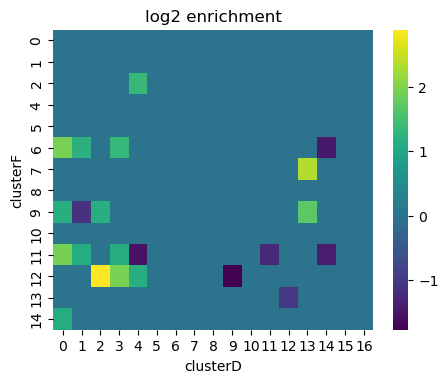

In [24]:
fig, ax = plot_cluster_overlap_heatmap(delta_log2_enrichment, title="log2 enrichment")

In [25]:
def plot_cluster_feature_signature_barplot(
    df,
    cluster_value,
    *,
    cluster_col="cluster",
    feature_cols=None,
    agg="mean",
    figsize=(4, 4),
    rotation=90,
):
    if feature_cols is None:
        feature_cols = [
            c for c in df.columns
            if c != cluster_col and pd.api.types.is_numeric_dtype(df[c])
        ]

    X = df[[cluster_col] + list(feature_cols)].copy()
    for c in feature_cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    if agg == "mean":
        prof = X.groupby(cluster_col)[feature_cols].mean()
    elif agg == "median":
        prof = X.groupby(cluster_col)[feature_cols].median()
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    plot_mat = (prof - prof.mean(axis=0)) / prof.std(axis=0).replace(0, np.nan)
    plot_mat = plot_mat.replace([np.inf, -np.inf], np.nan).fillna(0)

    if cluster_value not in plot_mat.index:
        raise ValueError(f"{cluster_value} not found in {cluster_col}")

    vals = plot_mat.loc[cluster_value]

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(vals.index.astype(str), vals.values, color="black")
    ax.axhline(0, linewidth=1)

    ax.set_ylim(-3, 3)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Z-score")
    ax.set_title(f"Feature signature for {cluster_col}={cluster_value}")
    ax.tick_params(axis="x", rotation=rotation)

    # remove box, keep only left and bottom axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, ax, vals

In [27]:
df_data = pd.read_csv('/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Figure3_4_Data.csv')

firstorderfeatures = ['Vol',"Dist_Nuc", "Dist_Mem", "Num_Connected_Objs", "Num_Branches"]
df_data = df_data[df_data['Condition']=='Control']

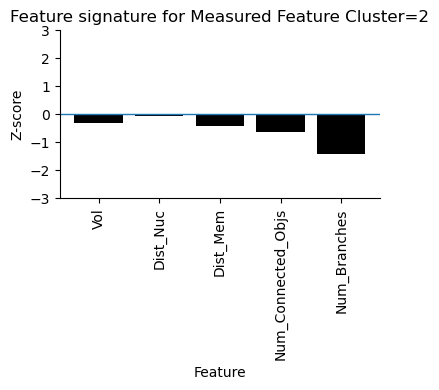

In [30]:
clustern = 2
fig, ax, result_df = plot_cluster_feature_signature_barplot(
    df_data,
    clustern,
    cluster_col="Measured Feature Cluster",
    feature_cols=firstorderfeatures
)

In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv('/net/bmc-lab8/data/lab/boyer/users/jhday/Sanofi Paper/June2026_Submission/data/Figure3_4_Data.csv')
# df=df[df['Condition']=='Control']
print(len(np.unique(df['ParentImage'])))

305
